In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_diabetes

x = load_diabetes().data
y = load_diabetes().target

x.shape,y.shape


((442, 10), (442,))

In [3]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((353, 10), (89, 10), (353,), (89,))

In [4]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train)
y_preds = lr.predict(x_test)


In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test,y_preds)
r2 = r2_score(y_test,y_preds)

print(f'MAE: {mae}, R2: {r2}')

MAE: 42.79409467959994, R2: 0.4526027629719197


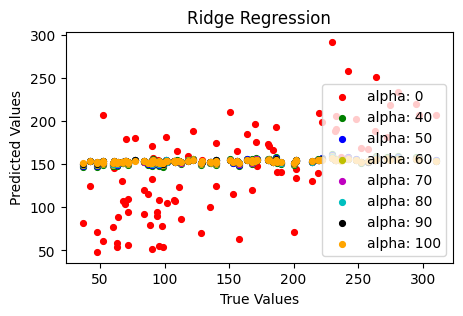

In [9]:
from sklearn.linear_model import Ridge

def pred_ridge(alpha):
    
    ridge = Ridge(alpha = alpha)
    ridge.fit(x_train,y_train)
    y_preds = ridge.predict(x_test)
    return y_preds

alpha = [0,40,50,60,70,80,90,100]
cs = ['r','g','b','y','m','c','k','orange']

plt.figure(figsize = (5,3))
for a,c in zip(alpha,cs):
    y_preds = pred_ridge(a)
    plt.scatter(y_test,y_preds,color = c, label = f'alpha: {a}', linewidth = 2, s = 10)


plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Ridge Regression')
plt.legend()
plt.show()




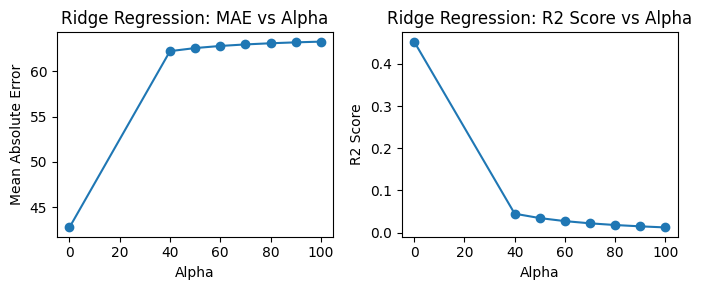

In [13]:
def error_ridge(alpha):
    ridge = Ridge(alpha = alpha)
    ridge.fit(x_train,y_train)
    y_preds = ridge.predict(x_test)
    mse = mean_absolute_error(y_test,y_preds)
    r2 = r2_score(y_test,y_preds)
    return mse,r2

alpha = [0,40,50,60,70,80,90,100]
mae_list = []
r2_list = []

for a in alpha:
    mae,r2 = error_ridge(a)
    mae_list.append(mae)
    r2_list.append(r2)
    
plt.figure(figsize = (7,3))
plt.subplot(1,2,1)
plt.plot(alpha,mae_list, marker = 'o')
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Error')
plt.title('Ridge Regression: MAE vs Alpha')
plt.subplot(1,2,2)
plt.plot(alpha,r2_list, marker = 'o')
plt.xlabel('Alpha')
plt.ylabel('R2 Score')
plt.title('Ridge Regression: R2 Score vs Alpha')
plt.tight_layout()
plt.show()

